In [1]:
#installation
# pip3 install torch torchvision (cpu)
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt
import pandas as pd 
from torch.random import manual_seed
import math

# Transformada Inversa

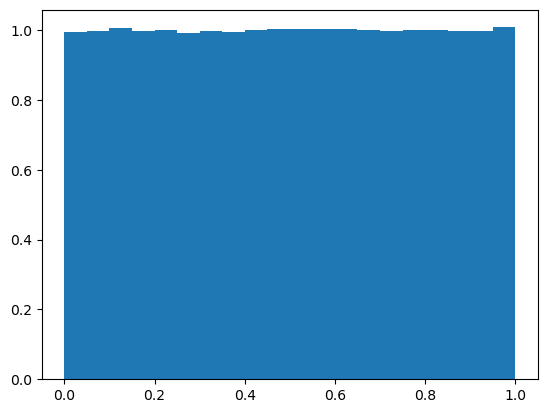

In [2]:
#Supongamos que solo sabemos simular uniformes
manual_seed(2**10)
n = 1000000
u = torch.rand((n,))
plt.hist(u, bins=20, density=True)
plt.show()

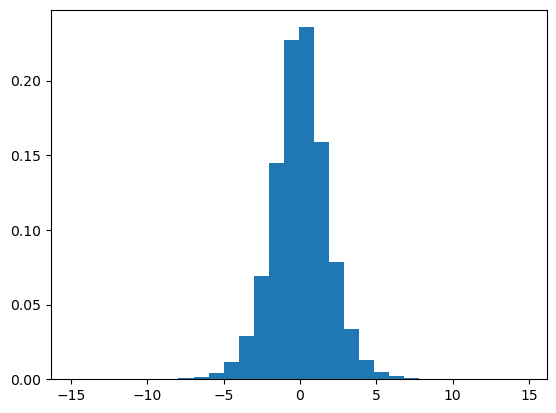

In [4]:
#simulamos de la Logística

x_logit = torch.logit(u)
plt.hist(x_logit, bins=30, density=True)
plt.show()

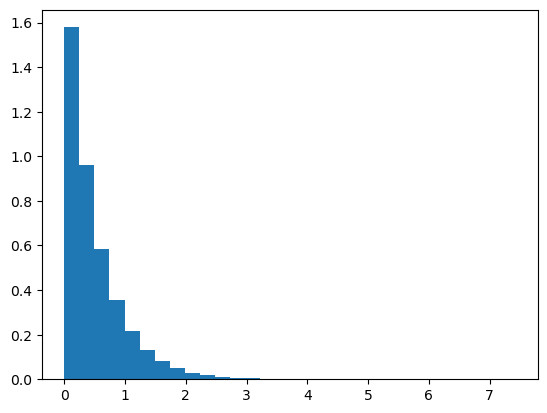

In [5]:
# Simulamos exponecial
lamb = 2.0
x_exp = -torch.log(u)/lamb
plt.hist(x_exp, bins=30, density=True)
plt.show()

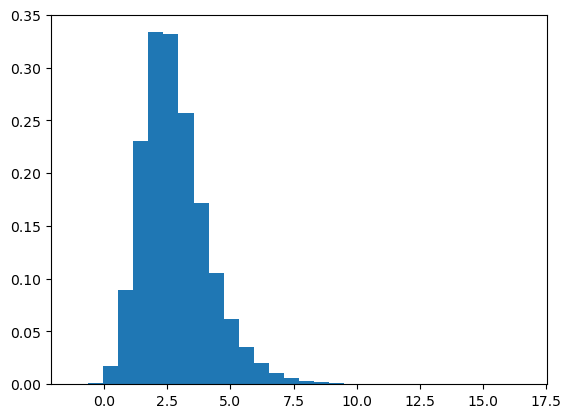

In [13]:
# Máximo de la logística tranformada inversa

k = 10
x_max = torch.logit(u**(1/k))
plt.hist(x_max, bins=30, density=True)
plt.show()

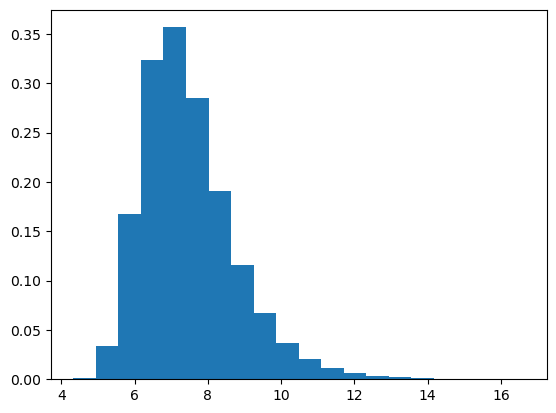

In [11]:
# Máximo de la logística usando máximo{x_1,..,x_k}
n_2 = 1000000
k_2 = 1000

u_2 = torch.rand((n_2,k_2))

x_logit2 = torch.logit(u_2)
x_max2 = torch.max(x_logit2, dim=1).values

plt.hist(x_max2, bins=20, density=True)
plt.show()

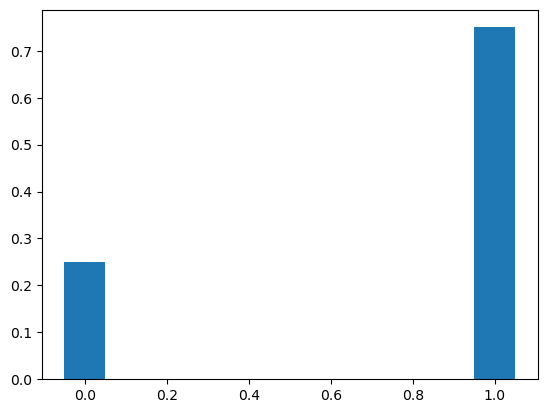

In [14]:
#Bernoulli
p = 3/4
x_ber = torch.where(u<1-p, 0.0, 1.0)

values, counts = torch.unique(x_ber, return_counts=True)
freq = counts / counts.sum()

plt.bar(values, freq, width=0.1)
plt.show()

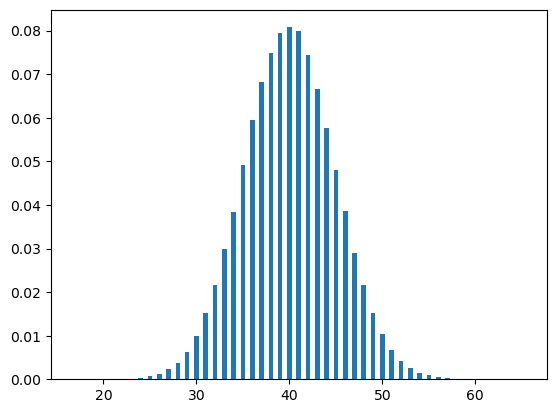

In [15]:
# Binomial(N,p)

N = 100
p = 2/5

a = -p/(1-p)
b = ((N+1)*p)/(1-p)
x_bin = []

for _ in range(n):
    
    p_0 = (1-p)**N
    S_p = p_0
    I = 0
    
    u_bin = torch.rand((1,)).item()
    
    while True:
    
        if u_bin < S_p:
    
            break
        else:
            
            I = I + 1 
            
            #if I > N:
                #I = N
                #break
                
            p_0 = p_0*(a+b/I)
            S_p = S_p + p_0

    x_bin.append(I)
        
x_bin = torch.Tensor(x_bin)

values, counts = torch.unique(x_bin, return_counts=True)
freq = counts / counts.sum()

plt.bar(values, freq, width=0.5)
plt.show()

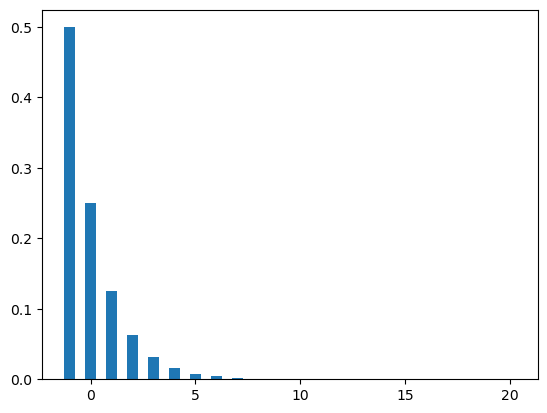

In [16]:
#Geometrica
p = 0.5
x_geo = torch.floor(torch.log(1-u)/torch.log(torch.tensor(1-p))-1)

values, counts = torch.unique(x_geo, return_counts=True)
freq = counts / counts.sum()

plt.bar(values, freq, width=0.5)
plt.show()

# Aceptación y Rechazo 

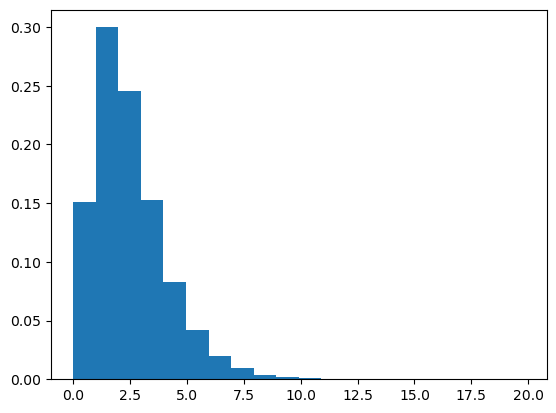

In [17]:
# Aceptación y Rechazo Gamma(alpha,1) alpha>1

alpha = 2.5
lamb = 1/alpha 

M = ((alpha-1)/(1-lamb))**(alpha-1)*math.exp(-alpha + 1)/(lamb*math.gamma(alpha))

def f_gamma(x):
    
    return (x ** (alpha - 1) * math.exp(-x)) / math.gamma(alpha)

def g_exp(x):
      
        return lamb * math.exp(-lamb * x)

muestras_aceptadas = []
intentos_totales = 0

while len(muestras_aceptadas) < n:
    
    intentos_totales += 1

    # Generar una propuesta Y de la distribución Exponencial(lamb)
    # Usamos el método de la transformada inversa: -ln(U)/lamb
    u1 = torch.rand((1,)).item()
    y = -math.log(u1) / lamb

    # Generar una variable uniforme para el criterio de rechazo
    u2 = torch.rand((1,)).item()

    # Condición de aceptación: U2 <= f(Y) / (M * g(Y))
    if u2 <= f_gamma(y) / (M * g_exp(y)):
        muestras_aceptadas.append(y)

x_gamma = torch.Tensor(muestras_aceptadas)
tasa_aceptacion = len(muestras_aceptadas) / intentos_totales
plt.hist(x_gamma, bins=20, density=True)
plt.show()

In [18]:
print(f"Tasa de aceptación teórica (1/M): {1/M:.4f}")
print(f"Tasa de aceptación simulada: {tasa_aceptacion:.4f}")


Tasa de aceptación teórica (1/M): 0.6029
Tasa de aceptación simulada: 0.6030


# Distribución Normal Estándar

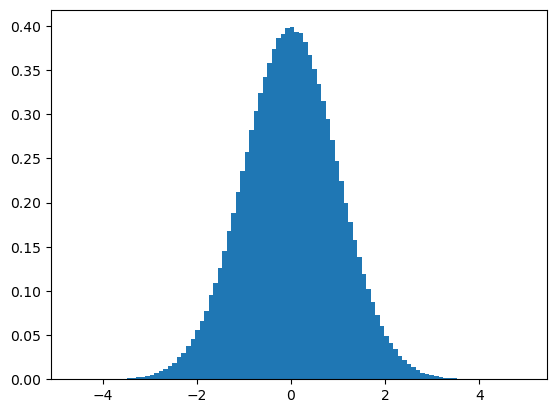

In [19]:
n = 1000000

U_norm = torch.rand((n,2))

x1_norm = torch.sqrt(-2*torch.log(U_norm[:,0]))*torch.cos(2*torch.pi*U_norm[:,1])
x2_norm = torch.sqrt(-2*torch.log(U_norm[:,0]))*torch.sin(2*torch.pi*U_norm[:,1])

plt.hist(x1_norm,bins=100,density=True)
plt.show()

# Mezcla de Normales

In [20]:
p_mix = 0.3
probs = torch.Tensor([p_mix, 1-p_mix])

Z_cate = dist.Categorical(probs)
x_zcate = Z_cate.sample((n,))

mu = [-2, 4]
sigma = [1.2, 1.5]

z1_norm = x1_norm*sigma[0] + mu[0]
z2_norm = x2_norm*sigma[1] + mu[1] 

x_mix = torch.where(x_zcate==0, z1_norm, z2_norm)

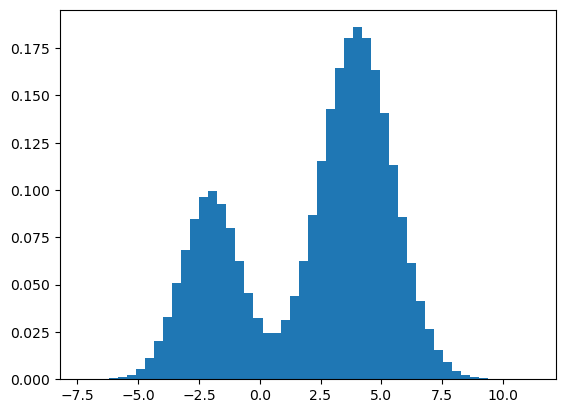

In [21]:
plt.hist(x_mix, bins=50, density=True)
plt.show()

In [22]:
#Mezclas con pytorch 
mix_dist = dist.Normal(torch.Tensor(mu),torch.Tensor(sigma)) 
         
norm_mix = dist.MixtureSameFamily(Z_cate, mix_dist)

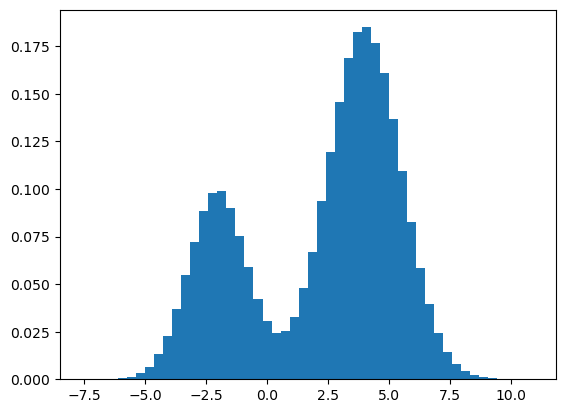

In [23]:
x_normmix = norm_mix.sample((n,))
plt.hist(x_normmix, bins=50, density=True)
plt.show()

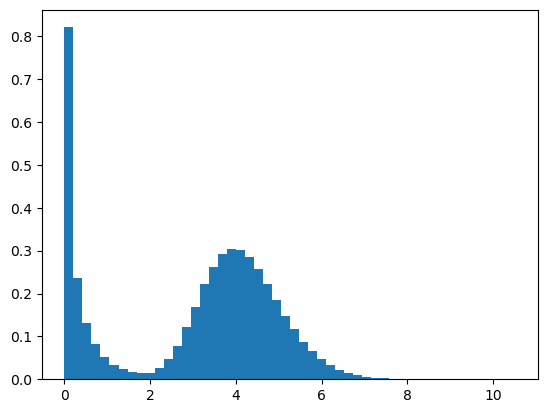

In [24]:
mix_dist_gam = dist.Gamma(torch.Tensor([0.5, 20.0]), torch.Tensor([1.5, 4.8])) 
         
gamm_mix = dist.MixtureSameFamily(Z_cate, mix_dist_gam)

x_gammmix = gamm_mix.sample((n,))
plt.hist(x_gammmix, bins=50, density=True)
plt.show()

# Vectores Aleatorios

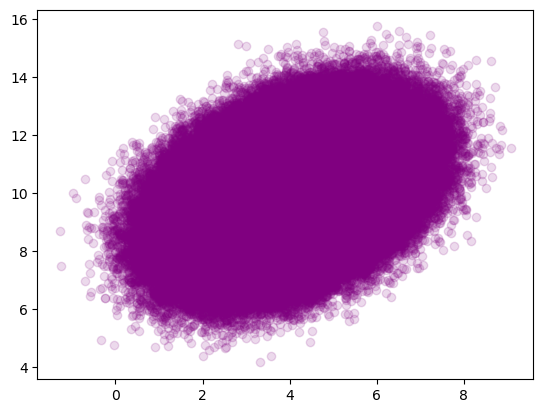

In [25]:
# Normal MUltivariada
mu = torch.Tensor([4, 10])
sigma = torch.Tensor([[1.2, 0.5], [0.5, 1.5]])

Mult_Norm = dist.MultivariateNormal(mu, sigma)

norm_mul_sample = Mult_Norm.sample((n,))

plt.scatter(norm_mul_sample[:,0], norm_mul_sample[:,1],alpha=0.15, 
            color='purple')
plt.show()

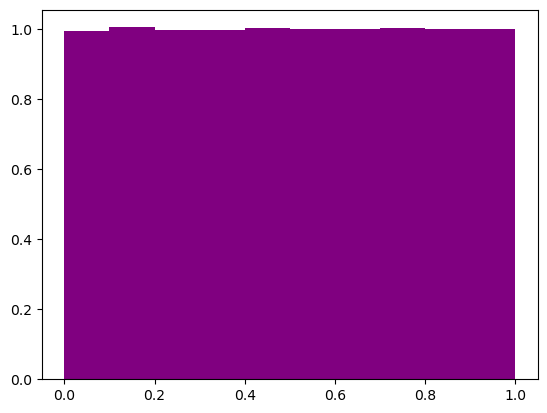

In [26]:
# Dirichlet 
alpha = torch.Tensor([1.0, 1.0])
Dirich = dist.Dirichlet(alpha)
dirich_samp = Dirich.sample((n,))

plt.hist(dirich_samp[:,0], color='purple', density=True)
plt.show()

In [27]:
#Normal INversa Gamma 

a = 8.5
b = 1.5
mu = torch.Tensor([4.5])

Y_gamma = dist.Gamma(a, b).sample((n,))

Varianza = 1.0 / Y_gamma
Desviacion = torch.sqrt(Varianza)

X_normal = dist.Normal(mu, Desviacion).sample()

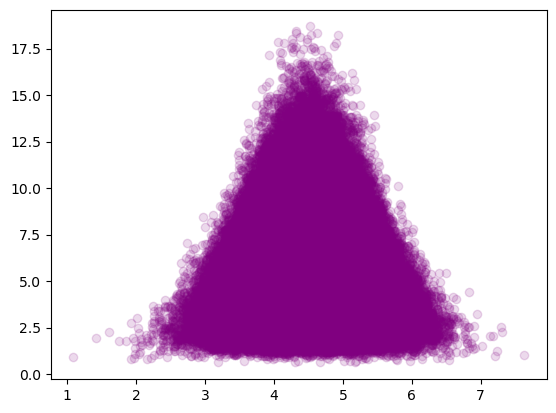

In [28]:
plt.scatter(X_normal, Y_gamma, alpha=0.15, 
            color='purple')
plt.show()

# Convergencia de Sucesiones 

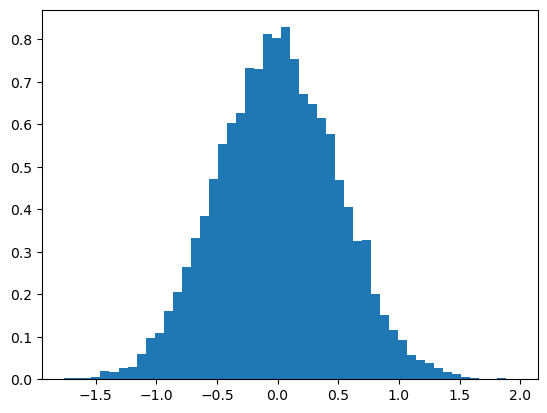

In [29]:
n_samples = 50000
trayectories = 10000
p = 0.5
Bern_dist = dist.Bernoulli(p)
bern_sample = Bern_dist.sample((n_samples,trayectories))

bern_sample_limit = math.sqrt(n_samples/p*(1-p))*(bern_sample.mean(dim=0)-p)
plt.hist(bern_sample_limit, bins=50, density=True)
plt.show()

In [30]:
bern_seq = bern_sample.cumsum(dim=0) / torch.arange(1, n_samples+1).unsqueeze(1)

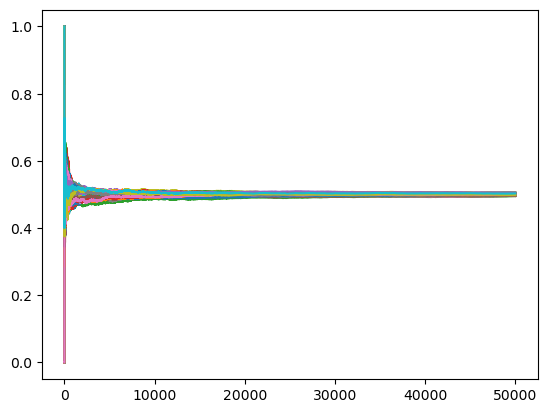

In [31]:
pd.DataFrame(bern_seq[:,:100]).plot(subplots=False, legend=False)
plt.show()

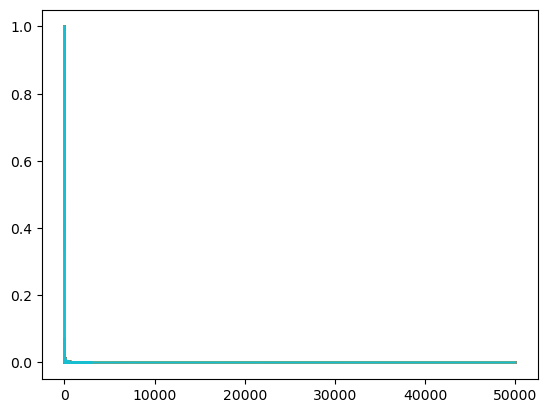

In [32]:
b_n = bern_sample[:,:100]/torch.arange(1, n_samples+1).unsqueeze(1)
pd.DataFrame(b_n[:,:100]).plot(subplots=False, legend=False)
plt.show()

# Proceso Poisson

In [2]:
class PoissonProcess:

    def __init__(self, rate = 1):

        self.rate = rate 

    def simulate(self, t = 1):
        
        S_t = [0]
        S = 0
        N = 0
        
        while S <= t :
            
            u = torch.rand((1,))
            T = -torch.log(u)/self.rate
            S += T.item()
            
            if S <= t:
                S_t.append(S)
                N += 1

        S_t.append(t)
        N_t = list(range(len(S_t)))
        N_t[-1] = N 
        
        return S_t, N_t

    def plot(self, t = 1):

        S_t, N_t = self.simulate(t) 
        plt.step(S_t, N_t, where='post')
        plt.xlabel('$t$')
        plt.ylabel('$N(t)$')
        plt.title('Proceso de Poisson')
        plt.grid(True)
        plt.show()

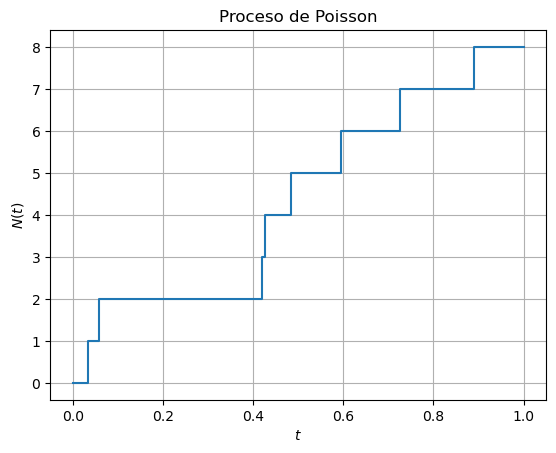

In [3]:
poi_proc = PoissonProcess(rate = 5)
poi_proc.plot()

# Cálculo de la $P(S_1\leq0.5)$

In [7]:
n = 1000000
lamb = 5
t = 1
# Simular el procfesos a tiempo t
N_t = dist.Poisson(lamb*t).sample((n,))
# Simulamos los el mínimo de n  uniformes en [0,t] dado N_t = n  
u_n = torch.rand((n))**(1/N_t)
S_1 = t*(1-u_n)
#Estimadores de la proba y de la varioanza
p_hat = (S_1<0.5).float().mean()
sigma_hat = torch.sqrt(p_hat*(1-p_hat)).item()

#cuantil 1-alpha/2
alpha = 0.05
z_alpha = dist.Normal(0,1).icdf(torch.tensor(1-alpha/2)).item()

#Intervalo de confianza
ci = (p_hat.item() - z_alpha*sigma_hat/math.sqrt(n), p_hat.item() + z_alpha*sigma_hat/math.sqrt(n))
#valor real
proba_real = 1-math.exp(-lamb*0.5)

print('Estimador: {:.4f}'.format(p_hat))
print ('CI: ({:.4f}, {:.4f})'.format(ci[0], ci[1]))
print('Proba real: {:.4f}'.format(proba_real))

Estimador: 0.9180
CI: (0.9175, 0.9185)
Proba real: 0.9179


# Proceso Poisson Compuesto

In [8]:

class CompoudPoissonProcess:

    def __init__(self, claims_dist ,rate = 1, ):

        self.rate = rate 
        self.claims_dist = claims_dist

    def simulate(self, t = 1):
        
        S_t = [0]
        X_t = [0]
        S = 0
        N = 0
        X = 0
        
        while S <= t :
            
            u = torch.rand((1,))
            T = -torch.log(u)/self.rate
            S += T.item()
            
            if S <= t:
                
                Y = self.claims_dist.sample((1,)).item()
                N += 1
                X +=Y
                S_t.append(S)
                X_t.append(X)
        

        S_t.append(t)
        N_t = list(range(len(S_t)))
        N_t[-1] = N 
        X_t.append(X_t[-1])
        
        return S_t, N_t, X_t

    def plot(self, t = 1):

        S_t, _ , X_t = self.simulate(t) 
        plt.step(S_t, X_t, where='post')
        plt.xlabel('$t$')
        plt.ylabel('$N(t)$')
        plt.title('Proceso de Poisson')
        plt.grid(True)
        plt.show()




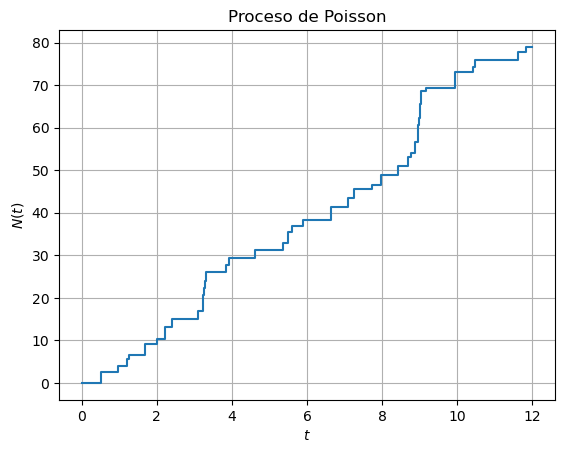

In [9]:
claims_dist = dist.Gamma(10,5)
com_poi_pro = CompoudPoissonProcess(claims_dist, rate = 4)
com_poi_pro.plot(t=12)

In [10]:
n = 50000
t = 12

X_t = torch.empty((n,))
for i in range(n):
    X_t[i] = com_poi_pro.simulate(t=t)[2][-1]
    

In [11]:
X_t.mean().item()

95.93794250488281

In [12]:
com_poi_pro.rate * com_poi_pro.claims_dist.mean.item() * t

96.0

In [13]:
X_t.std().item()

14.52670669555664

In [14]:
math.sqrt(com_poi_pro.rate*t*(com_poi_pro.claims_dist.variance + 
                              com_poi_pro.claims_dist.mean**2))

14.5327221196523

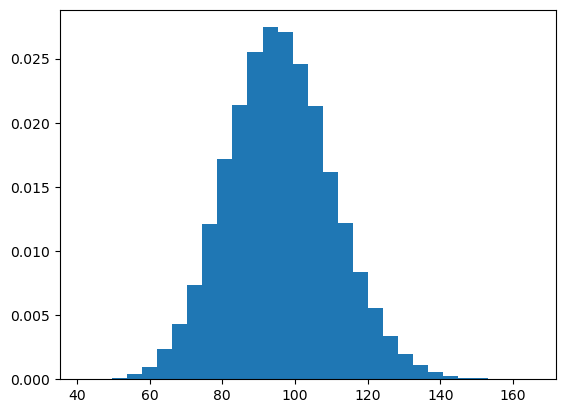

In [15]:
plt.hist(X_t, bins=30, density=True)
plt.show()

In [26]:
n = 100000
N_t = dist.Poisson(t*4).sample((n,))
X_t2 = N_t * claims_dist.mean
    

In [27]:
X_t2.mean()

tensor(95.9671)

In [28]:
X_t2.std()

tensor(13.8625)

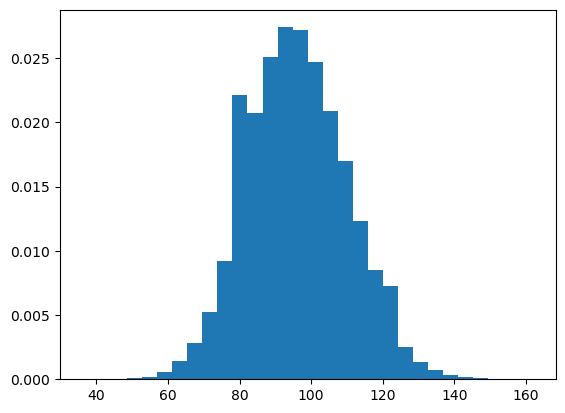

In [29]:
plt.hist(X_t2, bins=30, density=True)
plt.show()

In [30]:
(X_t2.mean().item() -1.96 * X_t2.std().item()/math.sqrt(n), 
 X_t2.mean().item() +1.96 * X_t2.std().item()/math.sqrt(n))

(95.8811358504146, 96.05297669841353)